# Optimal gate parameters for the GKP code: SNAP+D vs. ECD

Companion to the binomial-code notebook, same protocol applied to the square-lattice GKP code with
finite-energy envelope $\Delta$:

$$\ket{\mu_L} \propto \sum_{k,j} e^{-i\pi(k + \mu/2)j}\,
e^{-\varepsilon |d_{kj}|^2} \ket{d_{kj}}, \qquad
d_{kj} = (2k + \mu)\alpha + j\beta,$$

with primitive displacements $\alpha = \sqrt{\pi/2}$, $\beta = i\sqrt{\pi/2}$ and
$\varepsilon = \tfrac12(1 - e^{-2\Delta^2})$.

Three questions:

1. **Minimum circuit depth** for each gate set on (a) preparing $\ket{0_L}$ from vacuum, (b)
   preparing $\ket{1_L}$, (c) the logical $X_L$ on the code subspace.
2. **Which gate set is cheaper**, compared in parameter count and peak displacement amplitude rather
   than depth, since one ECD is not one SNAP.
3. **How the cost scales with $\Delta$.** Sharper GKP peaks mean higher $\bar n$ and more phase-space
   structure to synthesize, so $\Delta$ is the knob that sets the difficulty; loop 3 sweeps it.

Gates are ideal unitaries (no Kerr, no finite duration, no dispersive phase), so every fidelity is an
ansatz-limited upper bound on a real circuit of the same depth.

Two differences from the binomial notebook, both consequences of the target being a *grid* state
rather than a sparse Fock superposition. The truncation has to be much larger, since
$\bar n \approx (2\Delta^2)^{-1}$ before any circuit displacement is applied. And $X_L$ has a known
approximate implementation — a single displacement $D(\alpha)$ — which is used as a baseline that any
optimized circuit should beat.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import jax

jax.config.update("jax_enable_x64", True)  # before any array is created

import time

import jax.numpy as jnp
import jaxquantum as jqt
import matplotlib.pyplot as plt
import numpy as np

from gkp_optimal_control.gate_optimization import (
    GateBounds,
    OptimizerConfig,
    make_displacement,
    optimize_gate_sequence,
)
from gkp_optimal_control.plotting import (
    plot_photon_number,
    plot_wigner,
    set_plot_style,
)
from gkp_optimal_control.states import gkp_states
from gkp_optimal_control.utils import to_ket

set_plot_style()

Run parameters in one place. `N_FOCK` is the expensive dial here: every displacement is
$O(N_{\text{fock}}^3)$ to build and there are `n_gates` of them per seed per iteration, so the
truncation is what makes this notebook cost minutes-to-hours where the binomial one cost seconds. It
has to hold the sharpest target ($\Delta = 0.2$, $\bar n \approx 12$) *plus* whatever the circuit
displaces through mid-way, which is why `MAX_DISP` and `N_FOCK` have to be chosen together rather
than independently.

In [2]:
N_FOCK = 100          # truncation; must hold the Delta = 0.2 target plus mid-circuit excursions
N_LEAK = 10           # top Fock levels carrying the leakage penalty
MAX_DISP = 4.0        # soft cap on |beta| (ECD) / |alpha| (SNAP)
N_SNAP = 20           # Fock phases optimized per SNAP gate

# Square-lattice GKP.
GKP_ALPHA = jnp.sqrt(jnp.pi / 2)        # primitive displacement, logical Z axis
GKP_BETA = 1j * jnp.sqrt(jnp.pi / 2)    # primitive displacement, logical X axis
GKP_CUTOFF = 10                         # lattice-sum truncation, (2c+1)^2 peaks

DELTA_REF = 0.3                         # envelope for the depth sweeps
DELTAS = [0.2, 0.3, 0.4]                # loop 3

# Two thresholds: the sweep stops at TARGET_F, and STRETCH_F is reported for
# reference. Stopping at 0.999 for GKP would exhaust every depth grid.
TARGET_F = 0.99
STRETCH_F = 0.999

DISP_METHOD = "quadrature"
LOSS_TYPE = "log_infidelity"

BOUNDS = GateBounds(max_disp=MAX_DISP, n_leak=N_LEAK, leakage_weight=1.0)

# One optimizer budget for every point in the depth sweeps, so the curves are
# comparable: a depth that fails has failed at a fixed budget, not fixed effort.
OPT = OptimizerConfig(
    n_seeds=16,
    n_adam_iters=2500,
    peak_lr=0.03,
    polish=True,
    polish_maxiter=1000,
    seed=0,
)

# Longer, gentler settings for warm-start refinement of the winning runs.
OPT_POLISH = OptimizerConfig(
    n_adam_iters=2000, peak_lr=0.004, polish=True, polish_maxiter=3000
)

# Loop 3: fewer seeds, since most Delta points are warm-started.
OPT_DELTA = OptimizerConfig(
    n_seeds=12, n_adam_iters=2500, peak_lr=0.03, polish=True,
    polish_maxiter=1000, seed=7,
)

## Code states

`gkp_states` builds the finite-energy logicals as a weighted lattice sum of coherent states. Unlike
the binomial words these are $\Delta$-dependent and not exactly orthogonal — the residual overlap
$\braket{0_L|1_L}$ is a finite-energy artifact and grows as $\Delta$ does, which matters for the
$X_L$ objective: a target pair that is not quite orthonormal caps the achievable coherent fidelity
independently of circuit depth.

The table below is the truncation sanity check. If the top-`N_LEAK` population of a *target* is not
negligible, `N_FOCK` is too small before optimization even starts.

In [3]:
STATES: dict[float, tuple] = {}


def gkp_pair(delta: float):
    # Cached (|0_L>, |1_L>) at a given envelope; both normalized Qarrays.
    if delta not in STATES:
        STATES[delta] = gkp_states(N_FOCK, GKP_ALPHA, GKP_BETA, delta, GKP_CUTOFF)
    return STATES[delta]


ns = jnp.arange(N_FOCK)


def state_diagnostics(state):
    probs = jnp.abs(to_ket(state)) ** 2
    return float(jnp.sum(ns * probs)), float(jnp.sum(probs[-N_LEAK:]))


vac = jqt.basis(N_FOCK, 0)

print(f"{'Delta':>6} {'n_bar(0_L)':>11} {'n_bar(1_L)':>11} "
      f"{'|<0_L|1_L>|':>12} {'tail(0_L)':>11}")
print("-" * 56)
for delta in DELTAS:
    g0, g1 = gkp_pair(delta)
    nbar0, tail0 = state_diagnostics(g0)
    nbar1, _ = state_diagnostics(g1)
    ovl = float(jnp.abs(jnp.vdot(to_ket(g0), to_ket(g1))))
    print(f"{delta:>6.2f} {nbar0:>11.2f} {nbar1:>11.2f} {ovl:>12.2e} {tail0:>11.2e}")

gkp_0, gkp_1 = gkp_pair(DELTA_REF)

 Delta  n_bar(0_L)  n_bar(1_L)  |<0_L|1_L>|   tail(0_L)
--------------------------------------------------------
  0.20       12.71       12.71     7.64e-05    6.43e-04
  0.30        5.83        5.85     6.80e-05    5.97e-07
  0.40        3.30        3.56     2.96e-03    1.52e-10


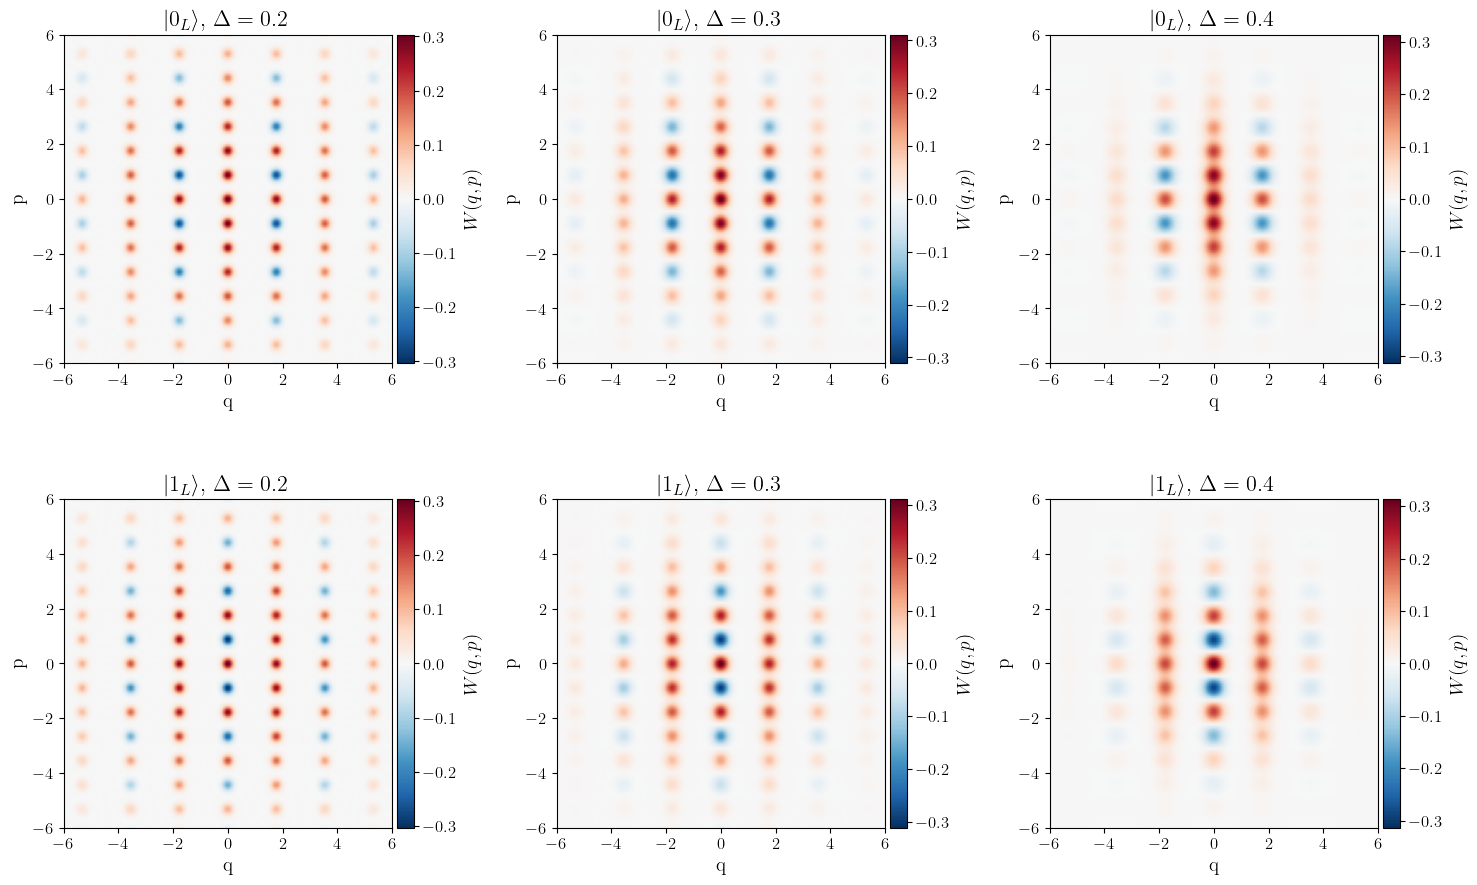

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
for col, delta in enumerate(DELTAS):
    g0, g1 = gkp_pair(delta)
    plot_wigner(g0, x_bound=6, y_bound=6, ax=axes[0][col],
                title=rf"$\ket{{0_L}}$, $\Delta = {delta}$")
    plot_wigner(g1, x_bound=6, y_bound=6, ax=axes[1][col],
                title=rf"$\ket{{1_L}}$, $\Delta = {delta}$")
fig.tight_layout()
plt.show()

## Tasks and objectives

| Task | Inputs | Targets | `batch_reduction` |
|---|---|---|---|
| `prep_0` | $\ket{0}$ | $\ket{0_L}$ | `"mean"` (single pair) |
| `prep_1` | $\ket{0}$ | $\ket{1_L}$ | `"mean"` (single pair) |
| `X_L` | $\ket{0_L}, \ket{1_L}$ | $\ket{1_L}, \ket{0_L}$ | `"coherent"` |

The reduction matters only for `X_L`. Averaging per-pair fidelities would let each logical state find
its own phase, so a high score would not certify a coherent gate; `"coherent"` averages the overlaps
before squaring, $F = |\overline{\braket{\psi_t|U|\psi_i}}|^2$, leaving one global phase free. The
two inputs span the code space, so constraining them coherently fixes the action on the subspace —
the $\ket{\pm_L}$ pairs are redundant.

Depth grids are much coarser and deeper than in the binomial case. GKP preparation from vacuum is the
canonical hard instance for both ansaetze, and stepping depth by 1 wastes budget when the interesting
range spans a factor of five.

In [5]:
def make_tasks(delta: float) -> dict:
    # Task table at a given envelope; states are cached across calls.
    g0, g1 = gkp_pair(delta)
    return {
        "prep_0": dict(psi_init=vac, psi_targ=g0, batch_reduction="mean",
                       label=r"prepare $\ket{0_L}$"),
        "prep_1": dict(psi_init=vac, psi_targ=g1, batch_reduction="mean",
                       label=r"prepare $\ket{1_L}$"),
        "X_L": dict(psi_init=[g0, g1], psi_targ=[g1, g0],
                    batch_reduction="coherent", label=r"logical $X_L$"),
    }


TASKS = make_tasks(DELTA_REF)

# n_gates counts ECDs or SNAPs, never total gates: the ECD ansatz carries
# n_gates + 1 rotations (4n + 2 parameters), the SNAP ansatz n_gates + 1
# displacements (n * N_SNAP + 2n + 2 parameters).
DEPTHS = {
    "snap": {"prep_0": [2, 4, 6, 8, 10, 12, 14],
             "prep_1": [2, 4, 6, 8, 10, 12, 14],
             "X_L": [2, 3, 4, 6, 8, 10, 12]},
    "ecd": {"prep_0": [4, 6, 8, 10, 12, 14, 16, 18, 20],
            "prep_1": [4, 6, 8, 10, 12, 14, 16, 18, 20],
            "X_L": [2, 4, 6, 8, 10, 12, 14, 16]},
}

## Baseline: $X_L$ as a single displacement

For the ideal (infinite-energy) code, $X_L$ is the displacement $D(\alpha)$ with
$\alpha = \sqrt{\pi/2}$: it shifts the lattice by half a period along $q$, mapping the even-$k$
sublattice onto the odd one. At finite $\Delta$ this is only approximate — the envelope is not
translation-invariant, so $D(\alpha)$ moves probability weight outward and the fidelity falls short
of one.

Scoring it with the same coherent objective the optimizer uses makes it a real baseline rather than a
rough comparison. Any circuit reported below that fails to beat this number is not doing useful work,
and the gap between the baseline and the optimized result is the honest measure of what the circuit
buys — the optimizer can exploit the envelope in ways a bare displacement cannot.

In [6]:
displace = make_displacement(N_FOCK, "expm")
D_alpha = displace(GKP_ALPHA)


def coherent_fidelity(unitary, inputs, targets):
    # F = |mean_k <t_k| U |i_k>|^2, matching batch_reduction="coherent".
    ov = jnp.array([
        jnp.vdot(to_ket(t), unitary @ to_ket(i)) for i, t in zip(inputs, targets)
    ])
    return float(jnp.abs(jnp.mean(ov)) ** 2)


X_BASELINE = {}
print(f"{'Delta':>6} {'F[D(alpha)]':>13} {'1 - F':>11}")
print("-" * 32)
for delta in DELTAS:
    g0, g1 = gkp_pair(delta)
    f_base = coherent_fidelity(D_alpha, [g0, g1], [g1, g0])
    X_BASELINE[delta] = f_base
    print(f"{delta:>6.2f} {f_base:>13.6f} {1 - f_base:>11.3e}")

 Delta   F[D(alpha)]       1 - F
--------------------------------
  0.20      0.940463   5.954e-02
  0.30      0.879071   1.209e-01
  0.40      0.807576   1.924e-01


## Sweep driver

`run_sweep` walks a depth grid at fixed budget and stops `n_extra` depths past the first success, so
the curve always contains at least one point beyond threshold. Results are keyed
`(gate_set, task)`; wall time is tracked separately since `GateOptResult` does not carry it.

In [7]:
RESULTS: dict[tuple[str, str], dict[int, object]] = {}
TIMINGS: dict[tuple[str, str], dict[int, float]] = {}


def run_gate_opt(gate_set, depth, spec, *, optimizer, bounds=BOUNDS, params0=None):
    # Single optimization with this notebook's fixed conventions.
    from gkp_optimal_control.gate_results import gate_result_path, load_gate_result, save_gate_result
    _path = gate_result_path('data/gate_results/gkp_code_gate_params', gate_set, depth)
    if _path.exists():
        _res = load_gate_result(_path)
        print("loaded cached result from " + str(_path))
    else:
        _res = optimize_gate_sequence(gate_set, depth, spec['psi_init'], spec['psi_targ'], n_fock=N_FOCK, n_snap=N_SNAP if gate_set == 'snap' else None, disp_method=DISP_METHOD, loss_type=LOSS_TYPE, batch_reduction=spec['batch_reduction'], bounds=bounds, optimizer=optimizer, params0=params0, verbose=False)
        save_gate_result(_res, _path, initial_state=spec['psi_init'], overwrite=True, source_notebook='gkp_code_gate_params')
    return _res



def run_sweep(gate_set, task, *, depths=None, target_f=TARGET_F, n_extra=1,
              optimizer=OPT, bounds=BOUNDS):
    # Sweep depth for one (gate_set, task) pair, stopping n_extra past
    # threshold; populates RESULTS[(gate_set, task)] and returns that dict.
    spec = TASKS[task]
    depths = DEPTHS[gate_set][task] if depths is None else depths
    store = RESULTS.setdefault((gate_set, task), {})
    times = TIMINGS.setdefault((gate_set, task), {})

    print(f"=== {gate_set:>4} | {task:<7} | depths {depths} | target F = {target_f} ===")
    hit_at = None
    for depth in depths:
        t0 = time.perf_counter()
        res = run_gate_opt(gate_set, depth, spec, optimizer=optimizer, bounds=bounds)
        elapsed = time.perf_counter() - t0
        store[depth] = res
        times[depth] = elapsed
        print(
            f"  n_gates = {depth:>2}  n_params = {res.flat_params.size:>4}  "
            f"1 - F = {1 - res.fidelity:.3e}  leak = {res.leakage:.1e}  "
            f"peak|d| = {res.params['disp_magnitudes'].max():.2f}  "
            f"({elapsed:.0f}s)"
        )
        if hit_at is None and res.fidelity >= target_f:
            hit_at = depth
            print(f"  -> threshold met at n_gates = {depth}")
        if hit_at is not None and depth >= hit_at + n_extra:
            break
    if hit_at is None:
        print("  -> threshold NOT met on this grid")
    print()
    return store


def curve(gate_set, task):
    # Sorted (depths, infidelities, n_params) arrays for one sweep.
    store = RESULTS.get((gate_set, task), {})
    depths = np.array(sorted(store))
    infid = np.array([1 - store[d].fidelity for d in depths])
    n_par = np.array([store[d].flat_params.size for d in depths])
    return depths, infid, n_par


def min_depth(gate_set, task, target_f=TARGET_F):
    # Smallest swept depth clearing target_f, or None.
    depths, infid, _ = curve(gate_set, task)
    ok = depths[infid <= 1 - target_f]
    return int(ok[0]) if ok.size else None


def best_result(gate_set, task, target_f=TARGET_F):
    # Result at min_depth if the threshold was met, else the highest-F run.
    store = RESULTS[(gate_set, task)]
    d = min_depth(gate_set, task, target_f)
    if d is None:
        d = max(store, key=lambda k: store[k].fidelity)
    return d, store[d]

## Loop 1 — SNAP + displacements

$$U = D(\alpha_{N+1}) \prod_{i=N}^{1} S(\vec\theta_i)\, D(\alpha_i), \qquad
S(\vec\theta) = \sum_n e^{i\theta_n}\ket{n}\bra{n}.$$

`N_SNAP = 20` pins the phases of levels $n \ge 20$ to zero. That cutoff is a real constraint here in
a way it was not for the binomial code: at $\Delta = 0.2$ the target has $\bar n \approx 12$ with
support well past $n = 20$, so the SNAP gates cannot address the whole state and the displacements
have to do proportionally more of the work. Raising `N_SNAP` will improve the numbers and is worth
sweeping — but only up to what selective qubit pulses can actually resolve.

In [8]:
for task in TASKS:
    run_sweep("snap", task)

=== snap | prep_0  | depths [2, 4, 6, 8, 10, 12, 14] | target F = 0.99 ===
  n_gates =  2  n_params =   46  1 - F = 2.958e-02  leak = 1.6e-31  peak|d| = 2.96  (62s)
  n_gates =  4  n_params =   90  1 - F = 4.688e-03  leak = 4.4e-24  peak|d| = 3.32  (104s)
  -> threshold met at n_gates = 4
  n_gates =  6  n_params =  134  1 - F = 4.303e-03  leak = 9.7e-31  peak|d| = 3.19  (145s)

=== snap | prep_1  | depths [2, 4, 6, 8, 10, 12, 14] | target F = 0.99 ===
  n_gates =  2  n_params =   46  1 - F = 1.685e-02  leak = 3.0e-31  peak|d| = 3.02  (60s)
  n_gates =  4  n_params =   90  1 - F = 6.166e-03  leak = 1.5e-20  peak|d| = 3.43  (102s)
  -> threshold met at n_gates = 4
  n_gates =  6  n_params =  134  1 - F = 5.436e-03  leak = 1.1e-30  peak|d| = 2.43  (144s)

=== snap | X_L     | depths [2, 3, 4, 6, 8, 10, 12] | target F = 0.99 ===
  n_gates =  2  n_params =   46  1 - F = 2.936e-02  leak = 7.9e-06  peak|d| = 0.90  (58s)
  n_gates =  3  n_params =   68  1 - F = 4.232e-02  leak = 1.8e-05  peak

## Loop 2 — ECD + qubit rotations

$$U = R(\theta_{N+1},\phi_{N+1}) \prod_{i=N}^{1} \mathrm{ECD}(\beta_i)\, R(\theta_i,\phi_i),
\qquad \mathrm{ECD}(\beta) = D(\beta/2)\ket{e}\bra{g} + D(-\beta/2)\ket{g}\bra{e}.$$

`qubit_target="ground"` (the default) throughout, so the reported $|\braket{\psi_t|\psi_g}|^2$
certifies both that the cavity arrived and that the ancilla returned to $\ket{g}$ disentangled.

This is the ansatz GKP preparation was designed around (Eickbusch *et al.*), and the expectation is
that it wins on parameter count despite needing several times the depth: $4N + 2$ parameters against
$N \cdot 20 + 2N + 2$. Expect this loop to dominate the notebook's runtime.

In [9]:
for task in TASKS:
    run_sweep("ecd", task)

===  ecd | prep_0  | depths [4, 6, 8, 10, 12, 14, 16, 18, 20] | target F = 0.99 ===
  n_gates =  4  n_params =   18  1 - F = 2.747e-01  leak = 4.6e-31  peak|d| = 2.69  (88s)
  n_gates =  6  n_params =   26  1 - F = 9.877e-02  leak = 1.6e-30  peak|d| = 2.62  (133s)
  n_gates =  8  n_params =   34  1 - F = 2.976e-02  leak = 1.3e-21  peak|d| = 3.66  (174s)
  n_gates = 10  n_params =   42  1 - F = 2.228e-02  leak = 2.2e-25  peak|d| = 2.36  (221s)
  n_gates = 12  n_params =   50  1 - F = 8.547e-03  leak = 4.8e-10  peak|d| = 3.37  (267s)
  -> threshold met at n_gates = 12
  n_gates = 14  n_params =   58  1 - F = 5.965e-03  leak = 3.0e-06  peak|d| = 3.47  (325s)

===  ecd | prep_1  | depths [4, 6, 8, 10, 12, 14, 16, 18, 20] | target F = 0.99 ===
  n_gates =  4  n_params =   18  1 - F = 2.065e-01  leak = 4.1e-31  peak|d| = 3.08  (89s)
  n_gates =  6  n_params =   26  1 - F = 1.425e-01  leak = 1.8e-25  peak|d| = 2.82  (132s)
  n_gates =  8  n_params =   34  1 - F = 6.637e-02  leak = 2.0e-15  pe

## Depth curves

Panels share axes so the gate sets read against each other per task. Solid line is the sweep
threshold, dotted the stretch threshold. A curve that flattens well above threshold has hit the
ansatz ceiling and needs depth, not seeds; one still falling at the last point is budget-limited and
worth extending.

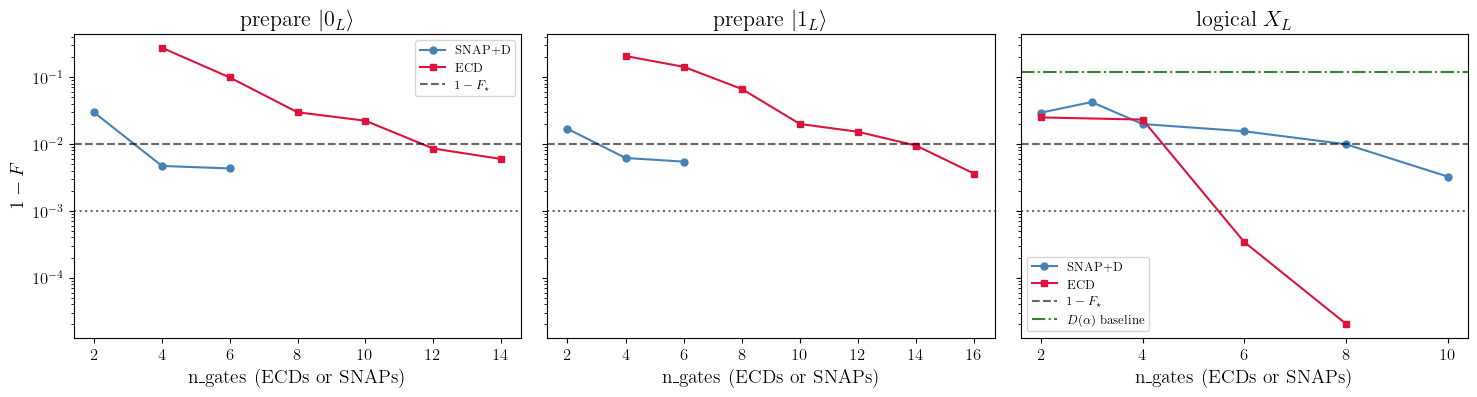

In [10]:
STYLE = {
    "snap": dict(color="steelblue", marker="o", label="SNAP+D"),
    "ecd": dict(color="crimson", marker="s", label="ECD"),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (task, spec) in zip(axes, TASKS.items()):
    for gate_set in ("snap", "ecd"):
        depths, infid, _ = curve(gate_set, task)
        if depths.size:
            ax.plot(depths, infid, linewidth=1.5, markersize=5, **STYLE[gate_set])
    ax.axhline(1 - TARGET_F, color="black", linestyle="--", alpha=0.6,
               label=r"$1 - F_\star$")
    ax.axhline(1 - STRETCH_F, color="black", linestyle=":", alpha=0.6)
    if task == "X_L":
        ax.axhline(1 - X_BASELINE[DELTA_REF], color="darkgreen", linestyle="-.",
                   alpha=0.8, label=r"$D(\alpha)$ baseline")
        ax.legend(fontsize=9)
    ax.set_yscale("log")
    ax.set_xlabel("n_gates (ECDs or SNAPs)")
    ax.set_title(spec["label"])
axes[0].set_ylabel(r"$1 - F$")
axes[0].legend(fontsize=9)
fig.tight_layout()
plt.show()

Same data against parameter count, the gate-set-agnostic axis: depth counts different objects in the
two ansaetze, but a parameter is a number a pulse compiler has to calibrate either way.

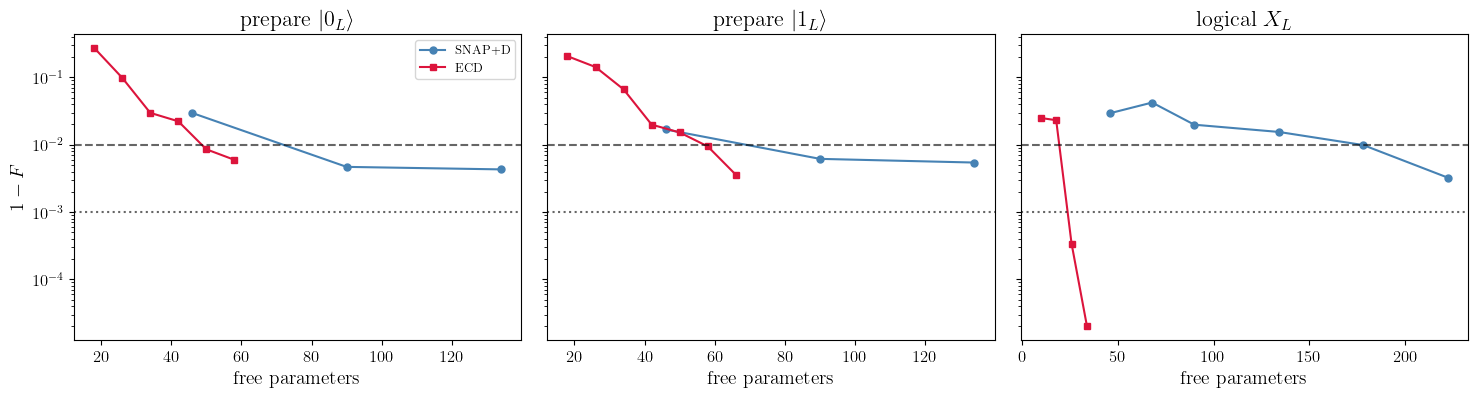

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (task, spec) in zip(axes, TASKS.items()):
    for gate_set in ("snap", "ecd"):
        depths, infid, n_par = curve(gate_set, task)
        if depths.size:
            ax.plot(n_par, infid, linewidth=1.5, markersize=5, **STYLE[gate_set])
    ax.axhline(1 - TARGET_F, color="black", linestyle="--", alpha=0.6)
    ax.axhline(1 - STRETCH_F, color="black", linestyle=":", alpha=0.6)
    ax.set_yscale("log")
    ax.set_xlabel("free parameters")
    ax.set_title(spec["label"])
axes[0].set_ylabel(r"$1 - F$")
axes[0].legend(fontsize=9)
fig.tight_layout()
plt.show()

## Resource table

Minimum depth clearing each threshold, and what the $F_\star$ circuit costs. `peak |d|` is the
hardware-facing number for the ECD set, since the required amplitude sets the gate duration and hence
the ancilla-decoherence exposure of that layer.

In [12]:
header = (
    f"{'task':<8} {'set':<5} {'d(F*)':>6} {'d(F**)':>7} {'params':>7} {'1-F':>10} "
    f"{'peak|d|':>8} {'leak':>9} {'seed spread':>20} {'time/run':>9}"
)
print(header)
print("-" * len(header))
for task in TASKS:
    for gate_set in ("snap", "ecd"):
        if (gate_set, task) not in RESULTS:
            continue
        d, res = best_result(gate_set, task)
        met = min_depth(gate_set, task) is not None
        d_stretch = min_depth(gate_set, task, STRETCH_F)
        spread = f"{res.per_seed_fidelity.min():.4f}..{res.per_seed_fidelity.max():.4f}"
        print(
            f"{task:<8} {gate_set:<5} "
            f"{str(d) + ('' if met else '*'):>6} "
            f"{('-' if d_stretch is None else str(d_stretch)):>7} "
            f"{res.flat_params.size:>7} {1 - res.fidelity:>10.2e} "
            f"{res.params['disp_magnitudes'].max():>8.2f} {res.leakage:>9.1e} "
            f"{spread:>20} {TIMINGS[(gate_set, task)][d]:>8.0f}s"
        )
print(f"\nF* = {TARGET_F}, F** = {STRETCH_F}. Depths marked * did not reach F* on the "
      "swept grid; the row shows the best depth tried.")
print(f"X_L displacement baseline at Delta = {DELTA_REF}: "
      f"1 - F = {1 - X_BASELINE[DELTA_REF]:.3e}")

task     set    d(F*)  d(F**)  params        1-F  peak|d|      leak          seed spread  time/run
--------------------------------------------------------------------------------------------------
prep_0   snap       4       -      90   4.69e-03     3.32   4.4e-24       0.9475..0.9948      104s
prep_0   ecd       12       -      50   8.55e-03     3.37   4.8e-10       0.9113..0.9915      267s
prep_1   snap       4       -      90   6.17e-03     3.43   1.5e-20       0.9300..0.9936      102s
prep_1   ecd       14       -      58   9.44e-03     2.68   2.4e-14       0.9325..0.9906      312s
X_L      snap       8       -     178   9.89e-03     1.94   1.3e-03       0.9156..0.9898      195s
X_L      ecd        6       6      26   3.41e-04     2.14   4.8e-06       0.8791..0.9997      143s

F* = 0.99, F** = 0.999. Depths marked * did not reach F* on the swept grid; the row shows the best depth tried.
X_L displacement baseline at Delta = 0.3: 1 - F = 1.209e-01


## Refining the winning circuits

Each minimum-depth solution is warm-started once with a long, low-learning-rate run plus an extended
L-BFGS-B polish. This separates *ansatz* capacity from *optimizer* convergence: if a depth that
missed threshold clears it after refinement, the sweep budget was the binding constraint and the
depth curves above are pessimistic. That distinction matters more here than for the binomial code,
because the GKP landscape is rougher and 16 seeds is a thin multi-start at these depths.

In [13]:
REFINED: dict[tuple[str, str], object] = {}

for task in TASKS:
    spec = TASKS[task]
    for gate_set in ("snap", "ecd"):
        if (gate_set, task) not in RESULTS:
            continue
        d, res = best_result(gate_set, task)
        ref = run_gate_opt(gate_set, d, spec, optimizer=OPT_POLISH,
                           params0=jnp.asarray(res.flat_params))
        keep = ref if ref.fidelity >= res.fidelity else res
        REFINED[(gate_set, task)] = keep
        print(
            f"{gate_set:>4} | {task:<7} | n_gates = {d:>2} : "
            f"1 - F  {1 - res.fidelity:.3e} -> {1 - ref.fidelity:.3e}"
            + ("" if keep is ref else "  (refinement rejected)")
        )

snap | prep_0  | n_gates =  4 : 1 - F  4.688e-03 -> 3.734e-03
 ecd | prep_0  | n_gates = 12 : 1 - F  8.547e-03 -> 8.547e-03
snap | prep_1  | n_gates =  4 : 1 - F  6.166e-03 -> 5.834e-03
 ecd | prep_1  | n_gates = 14 : 1 - F  9.440e-03 -> 9.440e-03
snap | X_L     | n_gates =  8 : 1 - F  9.887e-03 -> 8.325e-03
 ecd | X_L     | n_gates =  6 : 1 - F  3.411e-04 -> 3.411e-04


## Achieved states

For the ECD set `final_qarray()` returns the $\ket{g}$ block renormalized; with
`qubit_target="ground"` and a high fidelity that block carries essentially all the population. Grid
states are the case where the Wigner comparison earns its place — infidelity alone does not say
*which* peaks are wrong, and a solution that gets the central peaks right while losing the outer ones
looks very different from one with a uniform amplitude error.

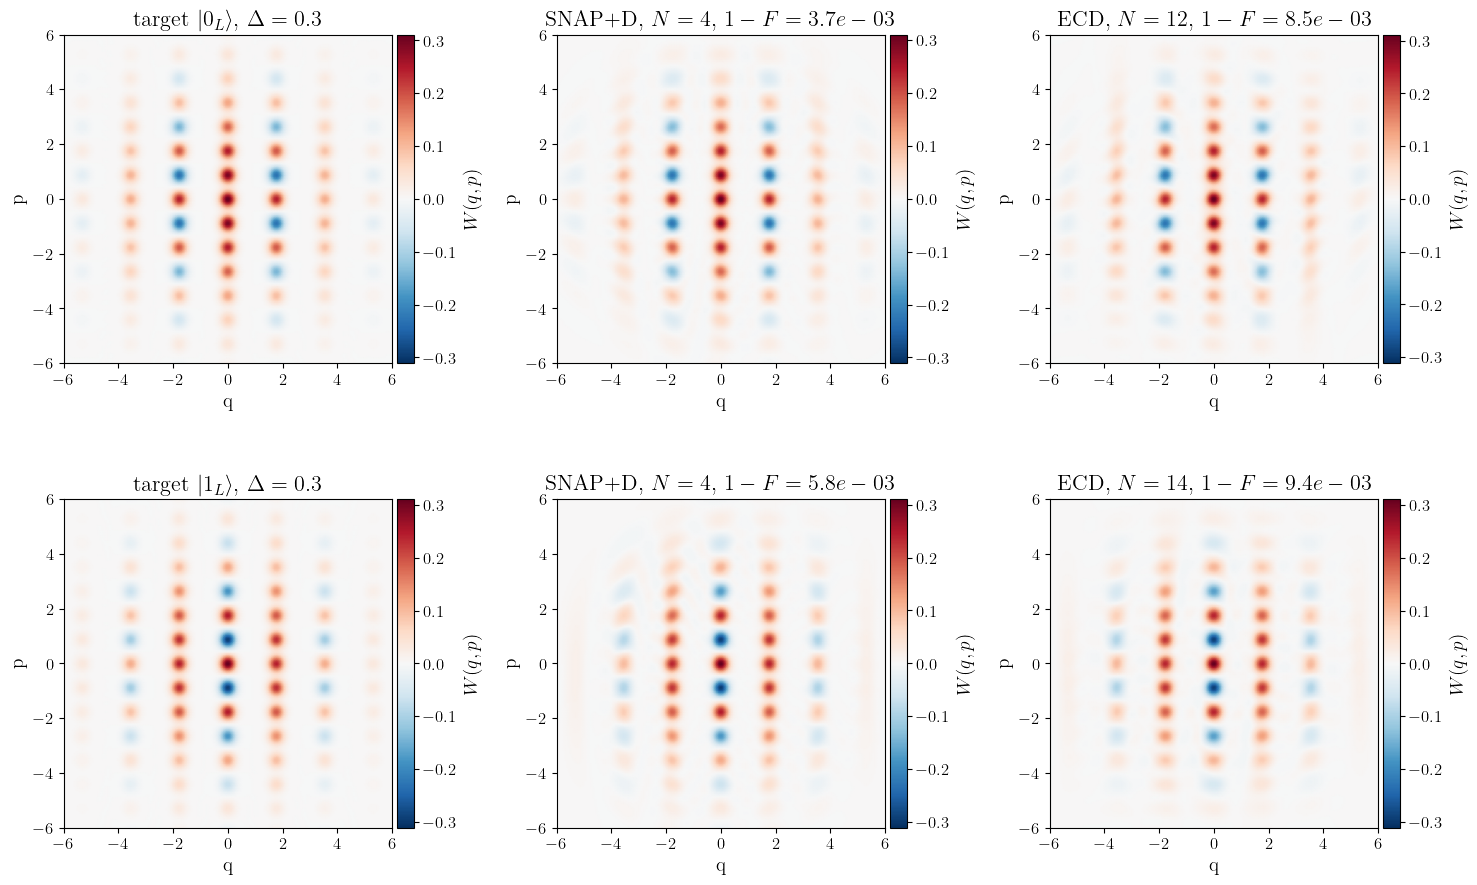

In [14]:
prep_tasks = ["prep_0", "prep_1"]
targets = {"prep_0": (gkp_0, r"0_L"), "prep_1": (gkp_1, r"1_L")}

fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
for row, task in enumerate(prep_tasks):
    target, name = targets[task]
    plot_wigner(target, x_bound=6, y_bound=6, ax=axes[row][0],
                title=rf"target $\ket{{{name}}}$, $\Delta = {DELTA_REF}$")
    for col, gate_set in enumerate(("snap", "ecd"), start=1):
        res = REFINED[(gate_set, task)]
        plot_wigner(
            res.final_qarray(), x_bound=6, y_bound=6, ax=axes[row][col],
            title=rf"{STYLE[gate_set]['label']}, $N={res.n_gates}$, "
                  rf"$1-F = {1 - res.fidelity:.1e}$",
        )
fig.tight_layout()
plt.show()

Photon-number distributions are the faster truncation check. A finite-energy GKP state has a broad,
structured $P(n)$, so the diagnostic here is not the shape but the tail: weight approaching
$n = $ `N_FOCK` means `MAX_DISP` and `N_FOCK` are mismatched and the reported fidelity is suspect.

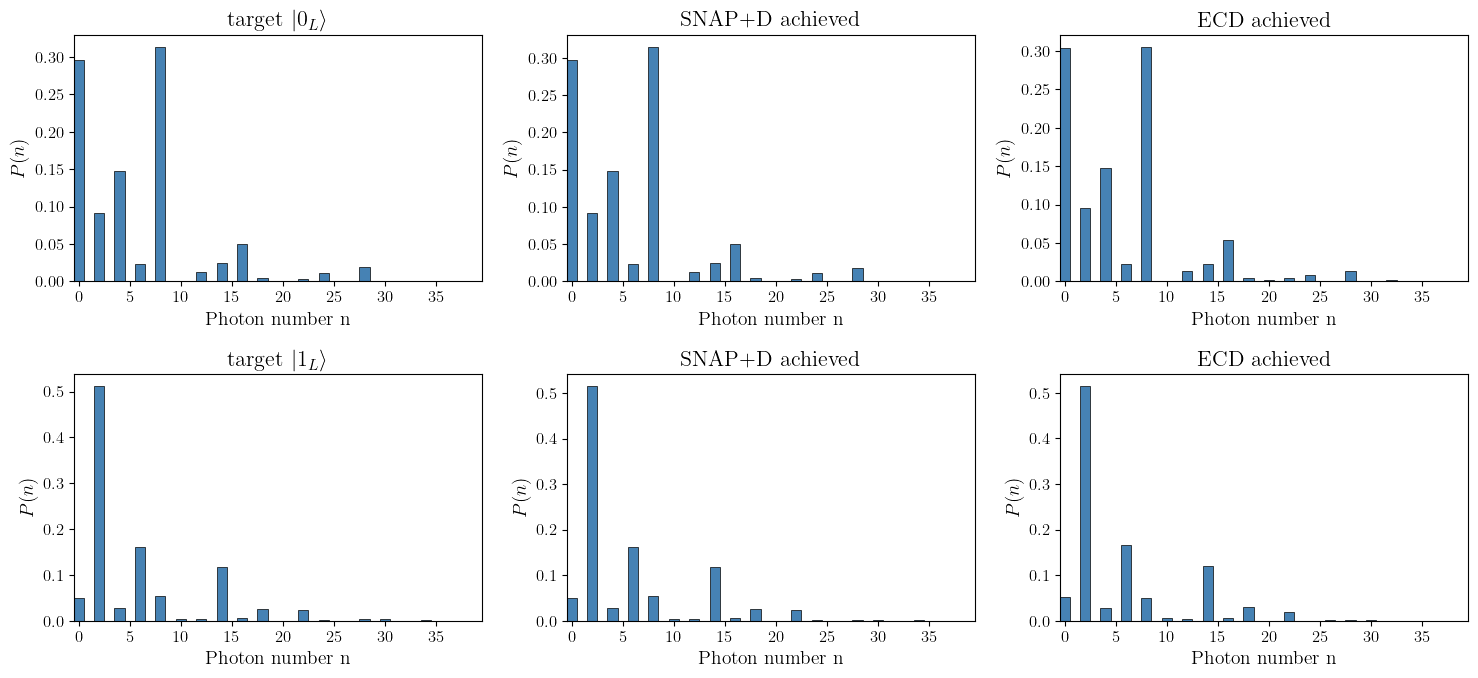

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for row, task in enumerate(prep_tasks):
    target, name = targets[task]
    plot_photon_number(target, ax=axes[row][0], max_n=40,
                       title=rf"target $\ket{{{name}}}$")
    for col, gate_set in enumerate(("snap", "ecd"), start=1):
        res = REFINED[(gate_set, task)]
        plot_photon_number(res.final_qarray(), ax=axes[row][col], max_n=40,
                           title=f"{STYLE[gate_set]['label']} achieved")
fig.tight_layout()
plt.show()

## Stabilizer expectation values

Fidelity to a particular $\Delta$ target is the wrong figure of merit if what you actually want is a
*good grid state*. The code-specific metric is the stabilizer expectation

$$\braket{S_q} = \mathrm{Re}\braket{D(2\alpha)}, \qquad
\braket{S_p} = \mathrm{Re}\braket{D(2\beta)},$$

which measures how sharply the state is pinned to the lattice, together with the effective
squeezing (Duivenvoorden *et al.*)

$$\Delta_{\text{eff}} = \sqrt{\frac{1}{2\pi}\,\ln\frac{1}{|\braket{S}|^2}},
\qquad |\braket{S}| = \tfrac12\left(|\braket{S_q}| + |\braket{S_p}|\right),$$

the envelope width the achieved state would have if it were an ideal finite-energy GKP state.

The overall normalization of $\Delta_{\text{eff}}$ is convention-dependent, so the table reports it
for the *targets* as well: comparing a target's $\Delta_{\text{eff}}$ against its known $\Delta$
calibrates the scale, and everything below is read as a ratio against that rather than as an
absolute.

A circuit can be slightly infidelitous in a benign way (right lattice, marginally wrong envelope) or
in a damaging way (right envelope, smeared peaks), and these two numbers separate those cases where
$1 - F$ cannot. Comparing $\Delta_{\text{eff}}$ of the achieved state against `DELTA_REF` is the
check worth reporting in a paper.

In [16]:
D_2alpha = displace(2 * GKP_ALPHA)
D_2beta = displace(2 * GKP_BETA)


def stabilizers(state):
    # (<S_q>, <S_p>, Delta_eff) for a single cavity ket.
    psi = to_ket(state)
    s_q = float(jnp.real(jnp.vdot(psi, D_2alpha @ psi)))
    s_p = float(jnp.real(jnp.vdot(psi, D_2beta @ psi)))
    s_bar = 0.5 * (abs(s_q) + abs(s_p))
    delta_eff = float(np.sqrt(np.log(1.0 / max(s_bar, 1e-12) ** 2) / (2 * np.pi)))
    return s_q, s_p, delta_eff


print(f"{'state':<26} {'<S_q>':>8} {'<S_p>':>8} {'Delta_eff':>10}")
print("-" * 56)
for task in prep_tasks:
    target, name = targets[task]
    print(f"{'target ' + name:<26}" + "".join(f"{v:>8.4f}" if i < 2 else f"{v:>10.4f}"
          for i, v in enumerate(stabilizers(target))))
    for gate_set in ("snap", "ecd"):
        res = REFINED[(gate_set, task)]
        label = f"  {STYLE[gate_set]['label']} N={res.n_gates}"
        print(f"{label:<26}" + "".join(f"{v:>8.4f}" if i < 2 else f"{v:>10.4f}"
              for i, v in enumerate(stabilizers(res.final_qarray()))))

state                         <S_q>    <S_p>  Delta_eff
--------------------------------------------------------
target 0_L                  0.7726  0.7867    0.2815
  SNAP+D N=4                0.7629  0.7737    0.2897
  ECD N=12                  0.7580  0.7687    0.2932
target 1_L                  0.7730  0.7867    0.2813
  SNAP+D N=4                0.7543  0.7722    0.2933
  ECD N=14                  0.7568  0.7609    0.2964


## The $X_L$ gate

Both logicals under one parameter set, against the $D(\alpha)$ baseline. `per_pair_fidelity` is
reported alongside the coherent figure to expose the failure mode where each pair reaches its target
individually but with a relative phase error between them: high per-pair values with a visibly lower
coherent $F$.

In [17]:
f_base = X_BASELINE[DELTA_REF]
print(f"baseline D(alpha)          : 1 - F = {1 - f_base:.3e}")
for gate_set in ("snap", "ecd"):
    res = REFINED[(gate_set, "X_L")]
    per_pair = np.asarray(res.params["per_pair_fidelity"])
    gain = (1 - f_base) / max(1 - res.fidelity, 1e-15)
    print(
        f"{STYLE[gate_set]['label']:<10} N = {res.n_gates:<3}    : "
        f"1 - F = {1 - res.fidelity:.3e}   per-pair F = {np.round(per_pair, 5)}   "
        f"phase penalty = {per_pair.mean() - res.fidelity:+.2e}   "
        f"infidelity gain over baseline = {gain:.1f}x"
    )

baseline D(alpha)          : 1 - F = 1.209e-01
SNAP+D     N = 8      : 1 - F = 8.325e-03   per-pair F = [0.99367 0.98969]   phase penalty = +1.02e-06   infidelity gain over baseline = 14.5x
ECD        N = 6      : 1 - F = 3.411e-04   per-pair F = [0.99972 0.9996 ]   phase penalty = +4.73e-08   infidelity gain over baseline = 354.5x


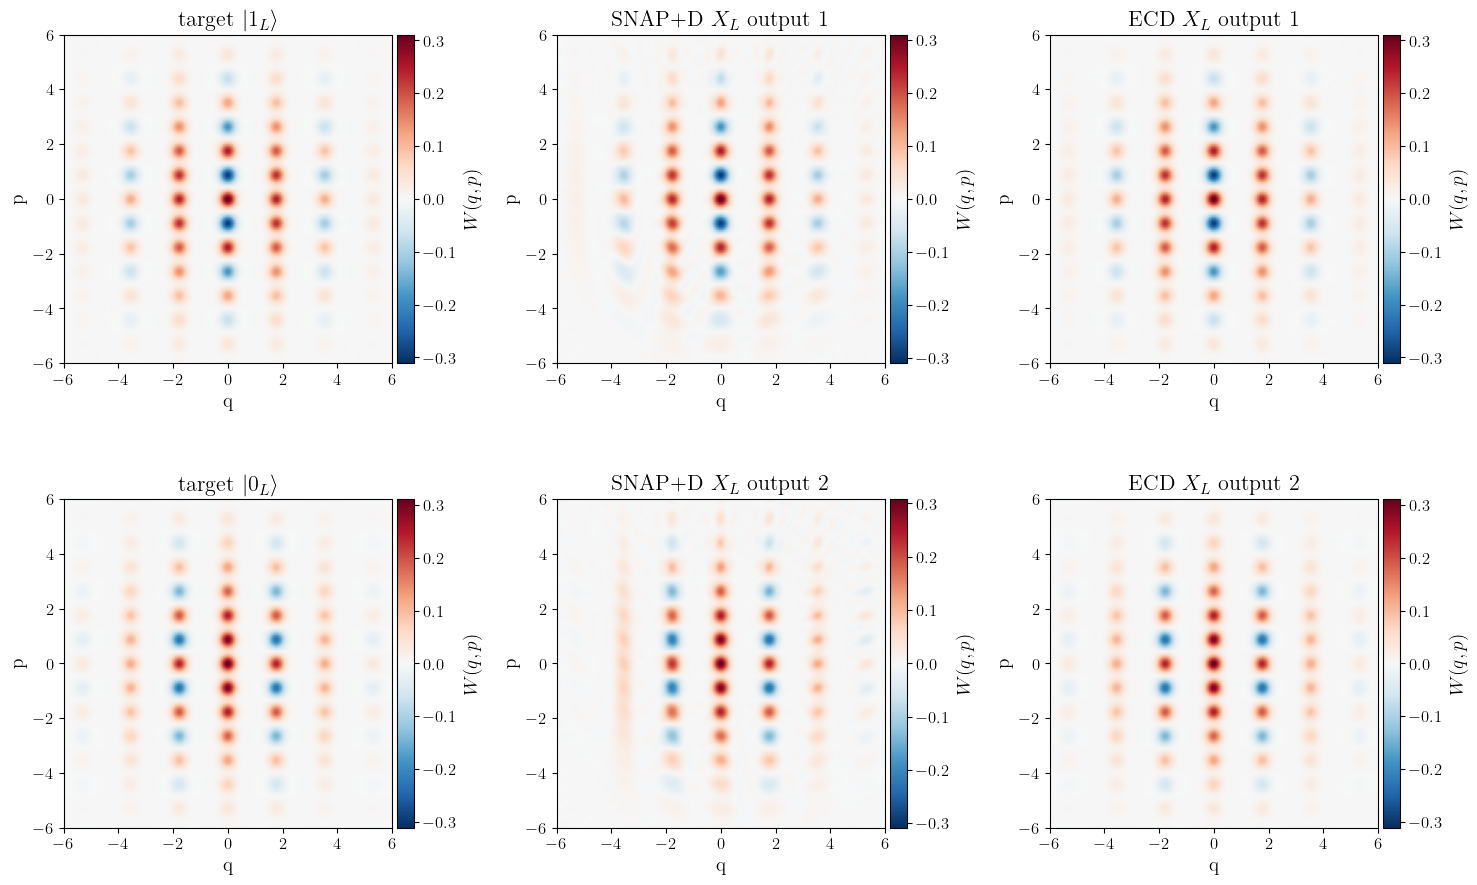

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9.5))
x_targets = [(gkp_1, r"1_L"), (gkp_0, r"0_L")]
for row, (target, name) in enumerate(x_targets):
    plot_wigner(target, x_bound=6, y_bound=6, ax=axes[row][0],
                title=rf"target $\ket{{{name}}}$")
    for col, gate_set in enumerate(("snap", "ecd"), start=1):
        res = REFINED[(gate_set, "X_L")]
        finals = res.final_qarray()
        plot_wigner(
            finals[row], x_bound=6, y_bound=6, ax=axes[row][col],
            title=rf"{STYLE[gate_set]['label']} $X_L$ output {row + 1}",
        )
fig.tight_layout()
plt.show()

## Convergence diagnostics

Adam traces over seeds and the final infidelity spread for each winning circuit. The plotted loss
includes the leakage and displacement penalties, so it is not a pure $\log(1-F)$. Wide spread means
the multi-start is doing real work and more seeds would help; a tight spread at high infidelity means
the ansatz is the limitation.

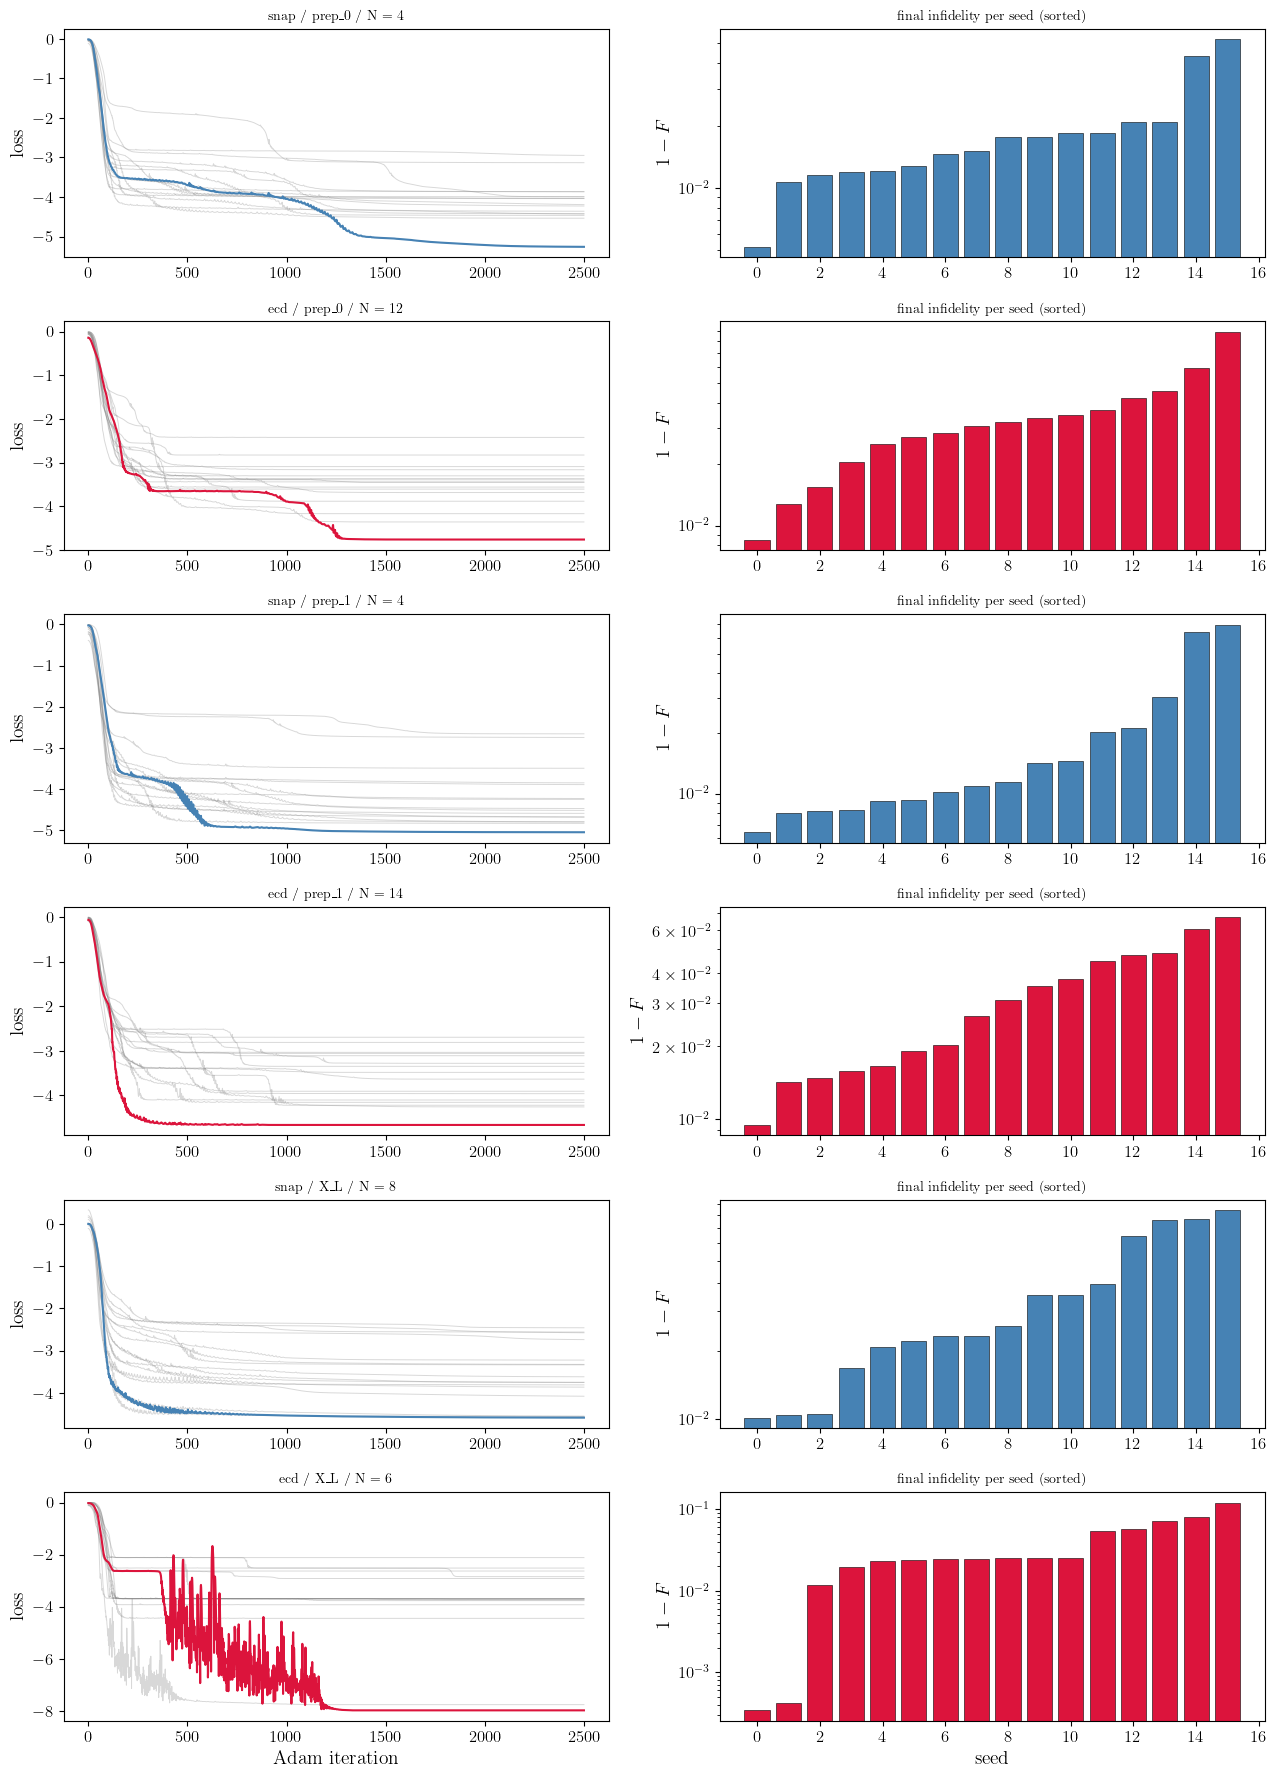

In [19]:
panels = [(gs, t) for t in TASKS for gs in ("snap", "ecd") if (gs, t) in RESULTS]

fig, axes = plt.subplots(len(panels), 2, figsize=(13, 3.0 * len(panels)))
axes = np.atleast_2d(axes)
for row, (gate_set, task) in enumerate(panels):
    d, res = best_result(gate_set, task)
    hist = np.asarray(res.adam_history)
    iters = np.arange(hist.shape[1])
    ax_h, ax_s = axes[row][0], axes[row][1]
    for k in range(hist.shape[0]):
        ax_h.plot(iters, hist[k], color="gray", alpha=0.3, linewidth=0.7)
    ax_h.plot(iters, hist[res.best_seed], color=STYLE[gate_set]["color"], linewidth=1.5)
    ax_h.set_ylabel("loss")
    ax_h.set_title(f"{gate_set} / {task} / N = {d}", fontsize=10)

    sorted_infid = 1 - np.sort(np.asarray(res.per_seed_fidelity))[::-1]
    ax_s.bar(np.arange(sorted_infid.size), sorted_infid,
             color=STYLE[gate_set]["color"], edgecolor="black", linewidth=0.4)
    ax_s.set_yscale("log")
    ax_s.set_ylabel(r"$1 - F$")
    ax_s.set_title("final infidelity per seed (sorted)", fontsize=10)
axes[-1][0].set_xlabel("Adam iteration")
axes[-1][1].set_xlabel("seed")
fig.tight_layout()
plt.show()

## Displacement amplitudes

The hardware-facing view. For ECD, $|\beta_i|$ sets the conditional displacement time; for SNAP it
sets how far the state leaves the low-Fock region where the selective pulses are valid. The dashed
line is the soft cap, and the penalty is quadratic in the excess, so layers sitting on it mean the
cap is actively binding and the reported fidelity is a constrained optimum — worth rerunning with a
larger `MAX_DISP` and `N_FOCK` before concluding anything about the ansatz.

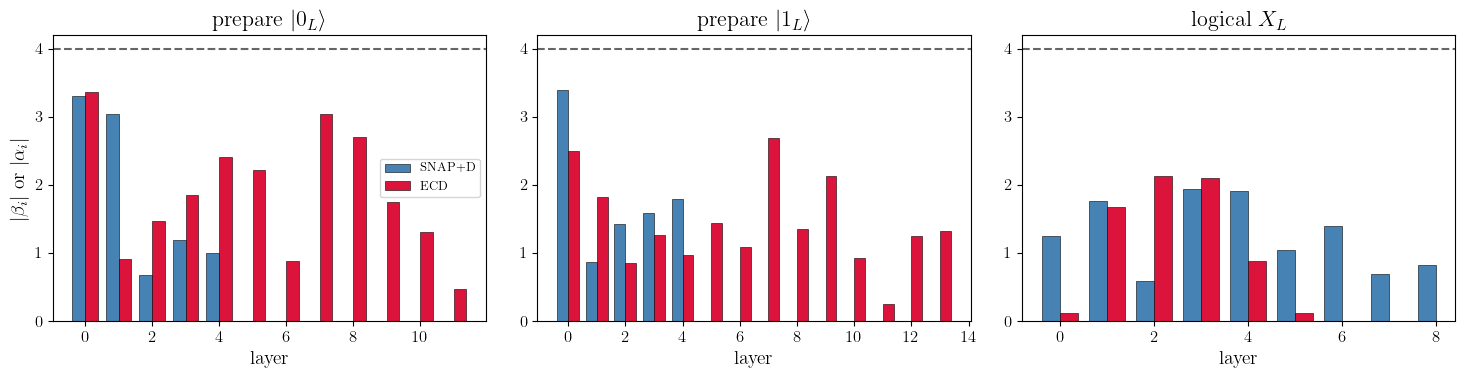

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
width = 0.38
for ax, (task, spec) in zip(axes, TASKS.items()):
    for k, gate_set in enumerate(("snap", "ecd")):
        if (gate_set, task) not in REFINED:
            continue
        mags = np.asarray(REFINED[(gate_set, task)].params["disp_magnitudes"])
        idx = np.arange(mags.size) + (k - 0.5) * width
        ax.bar(idx, mags, width=width, color=STYLE[gate_set]["color"],
               edgecolor="black", linewidth=0.4, label=STYLE[gate_set]["label"])
    ax.axhline(MAX_DISP, color="black", linestyle="--", alpha=0.6)
    ax.set_xlabel("layer")
    ax.set_title(spec["label"])
axes[0].set_ylabel(r"$|\beta_i|$ or $|\alpha_i|$")
axes[0].legend(fontsize=9)
fig.tight_layout()
plt.show()

## Loop 3 — envelope sweep

The GKP-specific loop. Depth is now held at whatever cleared threshold at `DELTA_REF`, and $\Delta$
is varied, so the question is how far a *fixed-cost* circuit degrades as the target sharpens.

Each off-reference point is warm-started from the reference solution at the same depth, which is both
cheaper and more informative than a cold restart: the two envelopes are genuinely nearby problems, so
a warm start that fails to converge says something about the landscape rather than about the seed
draw. If the warm start misses threshold, a cold multi-start is run as a fallback and the better of
the two is kept — the printout marks which won.

Expect $\Delta = 0.4$ to be easy (lower $\bar n$, fewer peaks inside the envelope) and
$\Delta = 0.2$ to fail at reference depth. The interesting output is the *shape* of that failure:
whether infidelity degrades smoothly with $\Delta$ or falls off a cliff once the target needs Fock
support beyond `N_SNAP` (SNAP) or more layers than are available (ECD).

In [21]:
DELTA_RESULTS: dict[tuple[str, str, float], object] = {}
DELTA_ORIGIN: dict[tuple[str, str, float], str] = {}

for delta in DELTAS:
    tasks_d = make_tasks(delta)
    print(f"=== Delta = {delta} ===")
    for task in tasks_d:
        for gate_set in ("snap", "ecd"):
            if (gate_set, task) not in REFINED:
                continue
            ref = REFINED[(gate_set, task)]
            depth = ref.n_gates
            if delta == DELTA_REF:
                DELTA_RESULTS[(gate_set, task, delta)] = ref
                DELTA_ORIGIN[(gate_set, task, delta)] = "reference"
                print(
                    f"  {gate_set:>4} | {task:<7} | N = {depth:>2} | "
                    f"1 - F = {1 - ref.fidelity:.3e} | reference (loop 1/2 result)"
                )
                continue
            spec = tasks_d[task]
            warm = run_gate_opt(gate_set, depth, spec, optimizer=OPT_POLISH,
                                params0=jnp.asarray(ref.flat_params))
            keep, origin = warm, "warm"
            if warm.fidelity < TARGET_F:
                cold = run_gate_opt(gate_set, depth, spec, optimizer=OPT_DELTA)
                if cold.fidelity > warm.fidelity:
                    keep, origin = cold, "cold"
            DELTA_RESULTS[(gate_set, task, delta)] = keep
            DELTA_ORIGIN[(gate_set, task, delta)] = origin
            print(
                f"  {gate_set:>4} | {task:<7} | N = {depth:>2} | "
                f"1 - F = {1 - keep.fidelity:.3e} | {origin}"
                + ("" if keep.fidelity >= TARGET_F else "  (below F*)")
            )
    print()

=== Delta = 0.2 ===
  snap | prep_0  | N =  4 | 1 - F = 6.286e-02 | warm  (below F*)
   ecd | prep_0  | N = 12 | 1 - F = 6.519e-02 | warm  (below F*)
  snap | prep_1  | N =  4 | 1 - F = 7.334e-02 | cold  (below F*)
   ecd | prep_1  | N = 14 | 1 - F = 4.609e-02 | cold  (below F*)
  snap | X_L     | N =  8 | 1 - F = 5.329e-02 | warm  (below F*)
   ecd | X_L     | N =  6 | 1 - F = 4.542e-04 | warm

=== Delta = 0.3 ===
  snap | prep_0  | N =  4 | 1 - F = 3.734e-03 | reference (loop 1/2 result)
   ecd | prep_0  | N = 12 | 1 - F = 8.547e-03 | reference (loop 1/2 result)
  snap | prep_1  | N =  4 | 1 - F = 5.834e-03 | reference (loop 1/2 result)
   ecd | prep_1  | N = 14 | 1 - F = 9.440e-03 | reference (loop 1/2 result)
  snap | X_L     | N =  8 | 1 - F = 8.325e-03 | reference (loop 1/2 result)
   ecd | X_L     | N =  6 | 1 - F = 3.411e-04 | reference (loop 1/2 result)

=== Delta = 0.4 ===
  snap | prep_0  | N =  4 | 1 - F = 1.371e-04 | warm
   ecd | prep_0  | N = 12 | 1 - F = 1.102e-03 | war

Infidelity against $\Delta$ at fixed depth, with the target's $\bar n$ on the second axis as the
difficulty proxy. Read the two together: a curve that tracks $\bar n$ is truncation- or
amplitude-limited, while one that degrades faster than $\bar n$ grows is running out of circuit
expressivity.

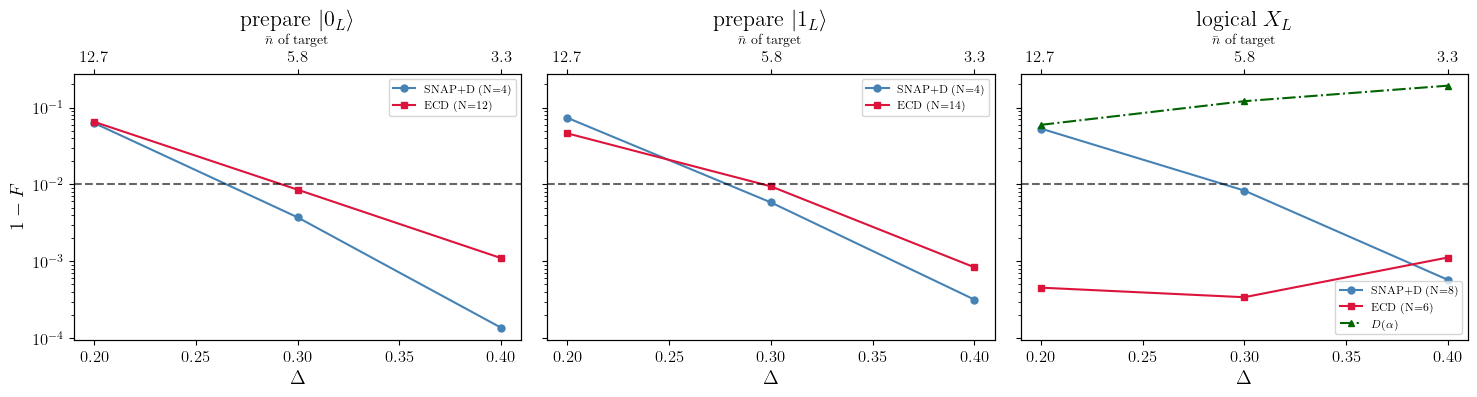

In [22]:
deltas_arr = np.array(DELTAS)
nbar_arr = np.array([state_diagnostics(gkp_pair(d)[0])[0] for d in DELTAS])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, (task, spec) in zip(axes, TASKS.items()):
    for gate_set in ("snap", "ecd"):
        pts = [(d, DELTA_RESULTS[(gate_set, task, d)]) for d in DELTAS
               if (gate_set, task, d) in DELTA_RESULTS]
        if not pts:
            continue
        xs = np.array([d for d, _ in pts])
        ys = np.array([1 - r.fidelity for _, r in pts])
        depth_note = pts[0][1].n_gates
        ax.plot(xs, ys, linewidth=1.5, markersize=5,
                color=STYLE[gate_set]["color"], marker=STYLE[gate_set]["marker"],
                label=f"{STYLE[gate_set]['label']} (N={depth_note})")
    if task == "X_L":
        ax.plot(deltas_arr, [1 - X_BASELINE[d] for d in DELTAS], color="darkgreen",
                linestyle="-.", marker="^", markersize=4, label=r"$D(\alpha)$")
    ax.axhline(1 - TARGET_F, color="black", linestyle="--", alpha=0.6)
    ax.set_yscale("log")
    ax.set_xlabel(r"$\Delta$")
    ax.set_title(spec["label"])
    ax.legend(fontsize=8)

    ax_top = ax.twiny()
    ax_top.set_xlim(ax.get_xlim())
    ax_top.set_xticks(deltas_arr)
    ax_top.set_xticklabels([f"{n:.1f}" for n in nbar_arr])
    ax_top.set_xlabel(r"$\bar n$ of target", fontsize=10)
axes[0].set_ylabel(r"$1 - F$")
fig.tight_layout()
plt.show()

Effective squeezing of the achieved states across $\Delta$, the stabilizer-based counterpart to the
plot above. The dashed reference is the *target's* own $\Delta_{\text{eff}}$ rather than the line
$\Delta_{\text{eff}} = \Delta$, which sidesteps the normalization convention: a circuit sitting on
that curve reproduced its target's lattice sharpness, and points above it are under-squeezed.

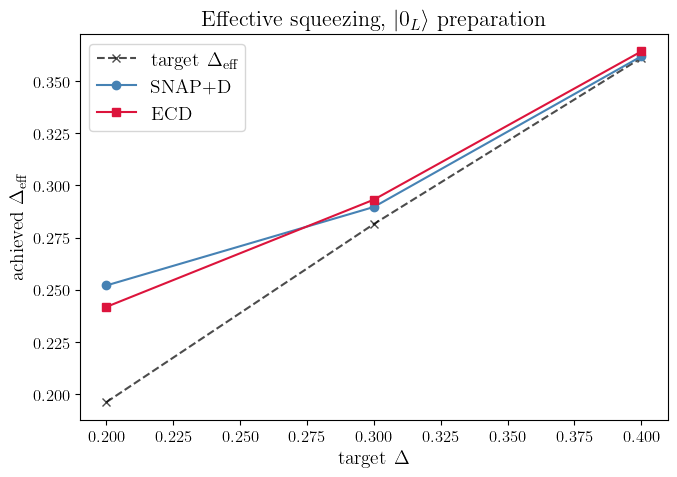

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
target_eff = np.array([stabilizers(gkp_pair(d)[0])[2] for d in DELTAS])
ax.plot(deltas_arr, target_eff, color="black", linestyle="--", marker="x",
        alpha=0.7, label=r"target $\Delta_{\rm eff}$")
for gate_set in ("snap", "ecd"):
    xs, ys = [], []
    for delta in DELTAS:
        key = (gate_set, "prep_0", delta)
        if key not in DELTA_RESULTS:
            continue
        xs.append(delta)
        ys.append(stabilizers(DELTA_RESULTS[key].final_qarray())[2])
    if xs:
        ax.plot(xs, ys, linewidth=1.5, markersize=6,
                color=STYLE[gate_set]["color"], marker=STYLE[gate_set]["marker"],
                label=STYLE[gate_set]["label"])
ax.set_xlabel(r"target $\Delta$")
ax.set_ylabel(r"achieved $\Delta_{\rm eff}$")
ax.set_title(r"Effective squeezing, $\ket{0_L}$ preparation")
ax.legend()
fig.tight_layout()
plt.show()

## Optimal parameters

The deliverable: labelled parameters for each refined circuit at `DELTA_REF`. ECD gives rotation
angles $(\theta_i, \phi_i)$ and complex $\beta_i$; SNAP gives the phase table $\theta_{i,n}$ and
complex $\alpha_i$.

In [24]:
for (gate_set, task), res in REFINED.items():
    print("=" * 72)
    print(f"{gate_set.upper()} | {task} | n_gates = {res.n_gates} | "
          f"1 - F = {1 - res.fidelity:.3e}")
    p = res.params
    if gate_set == "ecd":
        print("thetas :", np.round(np.asarray(p["thetas"]), 4))
        print("phis   :", np.round(np.asarray(p["phis"]), 4))
        print("betas  :", [f"{b:+.4f}" for b in np.asarray(p["betas"])])
    else:
        print("alphas :", [f"{a:+.4f}" for a in np.asarray(p["alphas"])])
        print(f"snap phases (n_gates x {N_SNAP}):")
        print(np.round(np.asarray(p["snap_phases"]), 4))

SNAP | prep_0 | n_gates = 4 | 1 - F = 3.734e-03
alphas : ['+1.9598+2.6598j', '+1.2466-2.7698j', '+0.1010+0.6692j', '+0.9609+0.6983j', '-0.9905-0.0841j']
snap phases (n_gates x 20):
[[-7.47000e-02 -1.43270e+00  2.62420e+00 -5.90730e+00  3.17440e+00
  -2.53390e+00  5.07200e-01 -3.16070e+00 -1.74130e+00 -9.80000e-03
  -4.03750e+00 -1.92110e+00 -5.81330e+00 -1.02403e+01 -9.69340e+00
  -3.03030e+00 -2.49410e+00 -5.86400e-01  1.49850e+00 -2.10450e+00]
 [-8.76800e-01  8.39000e-01 -7.67700e-01 -2.21450e+00  2.81480e+00
   4.73190e+00  1.34260e+00  1.77550e+00  1.89170e+00  6.78710e+00
   4.61000e-02  2.77640e+00  3.29460e+00 -2.96190e+00 -1.69460e+00
   5.69540e+00 -4.99390e+00  3.10500e+00  2.81900e+00 -3.33550e+00]
 [-5.43000e-01 -3.23750e+00  8.59200e-01 -1.96720e+00  2.38750e+00
  -3.86410e+00  3.75050e+00 -4.82890e+00 -1.46600e-01  3.01100e-01
   4.62410e+00  2.53170e+00 -2.46130e+00  1.82300e-01  3.70570e+00
   7.15960e+00 -2.54840e+00 -2.86320e+00  1.92990e+00  8.55240e+00]
 [ 1.86710e+

The SNAP phase table is meaningful only modulo $2\pi$ and is unconstrained on Fock levels the state
never populates, so wrapping it before comparing solutions avoids reading noise as structure. For
GKP the levels that matter extend much further up than for the binomial code, which makes the
`N_SNAP` cutoff visible directly in this plot as a hard right edge.

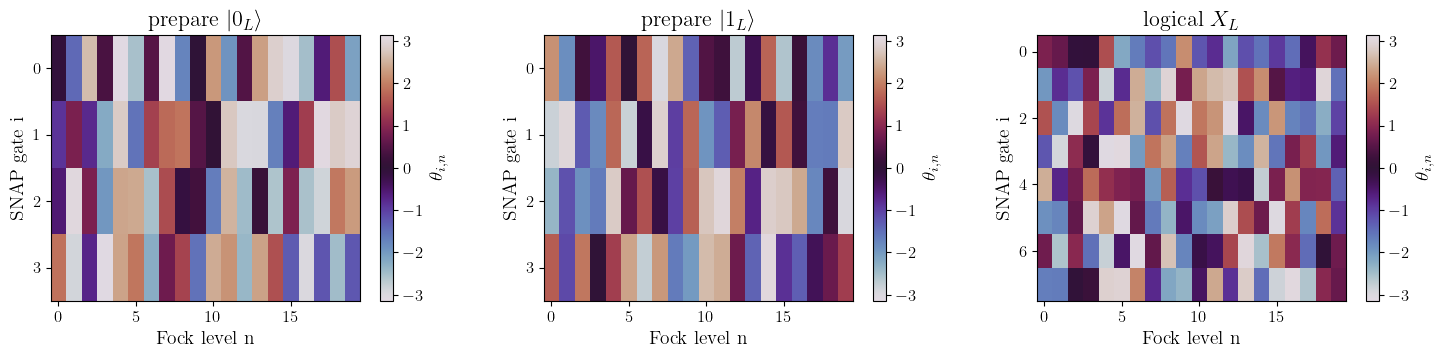

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (task, spec) in zip(axes, TASKS.items()):
    res = REFINED[("snap", task)]
    phases = np.asarray(res.params["snap_phases"])
    wrapped = (phases + np.pi) % (2 * np.pi) - np.pi
    im = ax.imshow(wrapped, aspect="auto", cmap="twilight", vmin=-np.pi, vmax=np.pi)
    ax.set_xlabel("Fock level n")
    ax.set_ylabel("SNAP gate i")
    ax.set_title(spec["label"])
    fig.colorbar(im, ax=ax, label=r"$\theta_{i,n}$")
fig.tight_layout()
plt.show()

## Export

Everything needed to reproduce or hand off a circuit: flat parameter vectors, the depth curves, and
the $\Delta$ sweep, in one `.npz`. `flat_params` is what `params0` takes for a warm start, so a saved
run can be pushed further — or moved to a nearby $\Delta$ — without repeating the sweep.

In [26]:
export = {
    "n_fock": N_FOCK,
    "n_snap": N_SNAP,
    "max_disp": MAX_DISP,
    "n_leak": N_LEAK,
    "target_f": TARGET_F,
    "stretch_f": STRETCH_F,
    "delta_ref": DELTA_REF,
    "deltas": np.array(DELTAS),
    "gkp_cutoff": GKP_CUTOFF,
    "code": "square-lattice GKP, alpha = sqrt(pi/2), beta = i sqrt(pi/2)",
    "x_baseline": np.array([X_BASELINE[d] for d in DELTAS]),
}
for (gate_set, task), res in REFINED.items():
    tag = f"{gate_set}_{task}"
    export[f"{tag}__flat_params"] = np.asarray(res.flat_params)
    export[f"{tag}__n_gates"] = res.n_gates
    export[f"{tag}__fidelity"] = res.fidelity
    export[f"{tag}__leakage"] = res.leakage

for (gate_set, task) in RESULTS:
    depths, infid, n_par = curve(gate_set, task)
    export[f"sweep_{gate_set}_{task}__depths"] = depths
    export[f"sweep_{gate_set}_{task}__infidelity"] = infid
    export[f"sweep_{gate_set}_{task}__n_params"] = n_par

for (gate_set, task, delta), res in DELTA_RESULTS.items():
    tag = f"delta_{gate_set}_{task}_{str(delta).replace('.', 'p')}"
    export[f"{tag}__flat_params"] = np.asarray(res.flat_params)
    export[f"{tag}__fidelity"] = res.fidelity
    export[f"{tag}__n_gates"] = res.n_gates
    export[f"{tag}__origin"] = DELTA_ORIGIN[(gate_set, task, delta)]

out_path = "gkp_gate_opt_results.npz"
np.savez(out_path, **export)
print(f"wrote {out_path}  ({len(export)} arrays)")

wrote gkp_gate_opt_results.npz  (125 arrays)


## Notes

Running log — fill in per run.

**Findings.**

- Minimum depths at $F_\star = 0.99$, $\Delta = 0.3$: SNAP `prep_0` / `prep_1` / `X_L` = _, _, _;
  ECD = _, _, _. At $F = 0.999$: _
- Cheaper gate set by parameter count: _
- Did any circuit beat the $D(\alpha)$ baseline on $X_L$, and by how much? _
- Was `MAX_DISP` binding at the winning depths? _
- $\Delta_{\text{eff}}$ of the achieved $\ket{0_L}$ vs. the target's $\Delta$: _
- Shape of the $\Delta$ degradation — smooth or cliff-like, and at which gate set first? _

**Open items.**

- Sweep `N_SNAP`. At $\Delta = 0.2$ the target has support well past $n = 20$, so the current cutoff
  probably limits the SNAP set more than depth does; the honest version of this plot has `N_SNAP` on
  one axis.
- Sweep `MAX_DISP` (with `N_FOCK` raised to match) for an infidelity-vs-amplitude tradeoff curve. The
  present single cap conflates the ansatz limit with the constraint.
- Rerun the ECD set with `echoed=False` to quantify what the echo is worth on grid states.
- Hexagonal lattice: same protocol with $\beta = e^{i\pi/3}\alpha$, where the better packing should
  reduce the depth needed at fixed $\Delta_{\text{eff}}$.
- Cross-check the winning ECD parameters against a pulse-level GRAPE run at matched duration. These
  are ideal-unitary numbers; the gap to a Kerr-including pulse solution is the quantity that decides
  whether depth or pulse fidelity is the binding constraint.
- Watch GPU memory at $N_{\text{fock}} = 100$ with 16 seeds and depth 20 — if it becomes the limit,
  drop `n_seeds` and run several batches with different `seed` values instead.